<img src="https://github.com/hernancontigiani/ceia_memorias_especializacion/raw/master/Figures/logoFIUBA.jpg" width="500" align="center">


# Procesamiento de lenguaje natural
## Custom embedddings con Gensim



### Objetivo
El objetivo es utilizar documentos / corpus para crear embeddings de palabras basado en ese contexto. Se utilizará canciones de bandas para generar los embeddings, es decir, que los vectores tendrán la forma en función de como esa banda haya utilizado las palabras en sus canciones.

In [172]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import multiprocessing
try:
  from gensim.models import Word2Vec
except:
  !pip install gensim
  from gensim.models import Word2Vec

# Detectar si estamos en Google Colab o en VS Code
try:
    import google.colab
    IN_COLAB = True
    RENDERER = "colab"
except ImportError:
    IN_COLAB = False
    RENDERER = "browser"

### Nota sobre renderización
El notebook detecta automáticamente si se está ejecutando en Google Colab o en VS Code y usa el renderer apropiado:
- **Google Colab**: `renderer="colab"` (renderiza en la salida de la celda)
- **VS Code**: `renderer="browser"` (abre los gráficos interactivos en navegador)

### Datos
Utilizaremos como dataset canciones de bandas de habla inglesa.

In [173]:
# Descargar la carpeta de dataset
import os
import platform
if os.access('./songs_dataset', os.F_OK) is False:
    if os.access('songs_dataset.zip', os.F_OK) is False:
        if platform.system() == 'Windows':
            !curl https://raw.githubusercontent.com/FIUBA-Posgrado-Inteligencia-Artificial/procesamiento_lenguaje_natural/main/datasets/songs_dataset.zip -o songs_dataset.zip
        else:
            !wget songs_dataset.zip https://github.com/FIUBA-Posgrado-Inteligencia-Artificial/procesamiento_lenguaje_natural/raw/main/datasets/songs_dataset.zip
    !unzip -q songs_dataset.zip
else:
    print("El dataset ya se encuentra descargado")

El dataset ya se encuentra descargado


In [174]:
# Posibles bandas
os.listdir("./songs_dataset/")

['prince.txt',
 'dickinson.txt',
 'notorious-big.txt',
 'beatles.txt',
 'bob-dylan.txt',
 'bjork.txt',
 'johnny-cash.txt',
 'disney.txt',
 'janisjoplin.txt',
 'kanye.txt',
 'bob-marley.txt',
 'leonard-cohen.txt',
 'ludacris.txt',
 'adele.txt',
 'alicia-keys.txt',
 'joni-mitchell.txt',
 'amy-winehouse.txt',
 'lorde.txt',
 'rihanna.txt',
 'Kanye_West.txt',
 'nirvana.txt',
 'cake.txt',
 'bieber.txt',
 'notorious_big.txt',
 'missy-elliott.txt',
 'dolly-parton.txt',
 'jimi-hendrix.txt',
 'michael-jackson.txt',
 'al-green.txt',
 'lil-wayne.txt',
 'lady-gaga.txt',
 'lin-manuel-miranda.txt',
 'nursery_rhymes.txt',
 'dj-khaled.txt',
 'radiohead.txt',
 'patti-smith.txt',
 'blink-182.txt',
 'Lil_Wayne.txt',
 'dr-seuss.txt',
 'r-kelly.txt',
 'drake.txt',
 'britney-spears.txt',
 'bruce-springsteen.txt',
 'nicki-minaj.txt',
 'kanye-west.txt',
 'paul-simon.txt',
 'nickelback.txt',
 'eminem.txt',
 'bruno-mars.txt']

In [175]:
# Armar el dataset utilizando salto de línea para separar las oraciones/docs
df = pd.read_csv('songs_dataset/beatles.txt', sep='/n', header=None)
df.head()

/var/folders/y7/m6l0m7cs4x74wr7kzyx5wjhh0000gn/T/ipykernel_3422/3849064916.py:2: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  df = pd.read_csv('songs_dataset/beatles.txt', sep='/n', header=None)


,0
0,"Yesterday, all my troubles seemed so far away"
1,Now it looks as though they're here to stay
2,"Oh, I believe in yesterday Suddenly, I'm not h..."
3,There's a shadow hanging over me.
4,"Oh, yesterday came suddenly Why she had to go ..."


In [176]:
print("Cantidad de documentos:", df.shape[0])

Cantidad de documentos: 1846


### 1 - Preprocesamiento

In [177]:
from tensorflow.keras.preprocessing.text import text_to_word_sequence

sentence_tokens = []
# Recorrer todas las filas y transformar las oraciones
# en una secuencia de palabras (esto podría realizarse con NLTK o spaCy también)
for _, row in df[:None].iterrows():
    sentence_tokens.append(text_to_word_sequence(row[0]))

In [178]:
# Demos un vistazo
sentence_tokens[:2]

[['yesterday', 'all', 'my', 'troubles', 'seemed', 'so', 'far', 'away'],
 ['now', 'it', 'looks', 'as', 'though', "they're", 'here', 'to', 'stay']]

### 2 - Crear los vectores (word2vec)

In [179]:
from gensim.models.callbacks import CallbackAny2Vec
# Durante el entrenamiento gensim por defecto no informa el "loss" en cada época
# Sobrecargamos el callback para poder tener esta información
class callback(CallbackAny2Vec):
    """
    Callback to print loss after each epoch
    """
    def __init__(self):
        self.epoch = 0

    def on_epoch_end(self, model):
        loss = model.get_latest_training_loss()
        if self.epoch == 0:
            print('Loss after epoch {}: {}'.format(self.epoch, loss))
        else:
            print('Loss after epoch {}: {}'.format(self.epoch, loss- self.loss_previous_step))
        self.epoch += 1
        self.loss_previous_step = loss

In [180]:
# Crearmos el modelo generador de vectores
# En este caso utilizaremos la estructura modelo Skipgram
w2v_model = Word2Vec(min_count=5,    # frecuencia mínima de palabra para incluirla en el vocabulario
                     window=2,       # cant de palabras antes y desp de la predicha
                     vector_size=300,       # dimensionalidad de los vectores
                     negative=20,    # cantidad de negative samples... 0 es no se usa
                     workers=1,      # si tienen más cores pueden cambiar este valor
                     sg=1)           # modelo 0:CBOW  1:skipgram



In [181]:
# Obtener el vocabulario con los tokens
w2v_model.build_vocab(sentence_tokens)

In [182]:
# Cantidad de filas/docs encontradas en el corpus
print("Cantidad de docs en el corpus:", w2v_model.corpus_count)

Cantidad de docs en el corpus: 1846


In [183]:
# Cantidad de words encontradas en el corpus
print("Cantidad de words distintas en el corpus:", len(w2v_model.wv.index_to_key))

Cantidad de words distintas en el corpus: 445


### 3 - Entrenar embeddings

In [184]:
# Entrenamos el modelo generador de vectores
# Utilizamos nuestro callback
w2v_model.train(sentence_tokens,
                 total_examples=w2v_model.corpus_count,
                 epochs=20,
                 compute_loss = True,
                 callbacks=[callback()]
                 )

Loss after epoch 0: 113045.2421875
Loss after epoch 1: 65966.5703125
Loss after epoch 2: 65935.015625
Loss after epoch 3: 65718.296875
Loss after epoch 4: 63874.96875
Loss after epoch 5: 64160.875
Loss after epoch 6: 64080.5
Loss after epoch 7: 64815.09375
Loss after epoch 8: 62632.75
Loss after epoch 9: 60452.75
Loss after epoch 10: 59839.6875
Loss after epoch 11: 58884.25
Loss after epoch 12: 57715.9375
Loss after epoch 13: 56494.1875
Loss after epoch 14: 55817.25
Loss after epoch 15: 55843.0625
Loss after epoch 16: 51722.6875
Loss after epoch 17: 49857.875
Loss after epoch 18: 49592.125
Loss after epoch 19: 48960.0


(156986, 287740)

### 4 - Ensayar

In [185]:
# Palabras que MÁS se relacionan con...:
w2v_model.wv.most_similar(positive=["darling"], topn=10)

[('pretty', 0.8954243063926697),
 ('sleep', 0.8665637969970703),
 ('help', 0.8439376950263977),
 ('cry', 0.83512943983078),
 ('not', 0.8309614658355713),
 ('try', 0.8276940584182739),
 ('peace', 0.8144854307174683),
 ('little', 0.8140544295310974),
 ('twist', 0.8123906850814819),
 ('seems', 0.8079560995101929)]

In [186]:
# Palabras que MENOS se relacionan con...:
w2v_model.wv.most_similar(negative=["love"], topn=10)

[('shake', -0.2287278026342392),
 ('four', -0.23302021622657776),
 ('five', -0.237460196018219),
 ('six', -0.2378387749195099),
 ('bang', -0.2483242005109787),
 ('our', -0.25538891553878784),
 ('day', -0.2689763307571411),
 ('going', -0.2692073881626129),
 ('here', -0.26990994811058044),
 ('three', -0.28389739990234375)]

In [187]:
# Palabras que MÁS se relacionan con...:
w2v_model.wv.most_similar(positive=["four"], topn=10)

[('five', 0.9813730716705322),
 ('three', 0.9745771884918213),
 ('six', 0.9710819721221924),
 ('seven', 0.9584385752677917),
 ('two', 0.9517235159873962),
 ('sixty', 0.8990404605865479),
 ('one', 0.7951188683509827),
 ('crying', 0.7946323752403259),
 ('us', 0.774010956287384),
 ("i'm", 0.7508406639099121)]

In [188]:
# Palabras que MÁS se relacionan con...:
w2v_model.wv.most_similar(positive=["money"], topn=5)

[("can't", 0.9434012770652771),
 ('buy', 0.9396973252296448),
 ('much', 0.9033190011978149),
 ('just', 0.8509107828140259),
 ('hide', 0.8355358839035034)]

In [189]:
# Ensayar con una palabra que no está en el vocabulario:
#w2v_model.wv.most_similar(negative=["diedaa"])

In [190]:
# el método `get_vector` permite obtener los vectores:
vector_love = w2v_model.wv.get_vector("love")
print(vector_love)

[ 0.06138294  0.05881053 -0.06370477  0.02445546 -0.20152311 -0.18612298
 -0.15284492  0.4548641  -0.042179    0.03535716  0.13657664 -0.1851985
 -0.18126567  0.22149132 -0.3038017  -0.23970504  0.0709474  -0.05679084
 -0.05165781 -0.23843321 -0.08529595  0.19564523 -0.07678778  0.03796823
  0.07516409 -0.04826145  0.07379413  0.10396487  0.00737745 -0.22765112
 -0.04566921  0.1293697   0.27785546  0.19387001 -0.13509622  0.20857269
  0.4091703  -0.00386562 -0.10631571 -0.09057102  0.02400816 -0.08005267
  0.13399461  0.08833719 -0.01894974  0.08592648 -0.15905555  0.10259393
  0.1445954  -0.1209247  -0.279195   -0.04061342  0.11381969  0.31366253
 -0.07408687  0.1397688   0.22791368  0.1320968  -0.01811604  0.09772383
  0.09249984 -0.14871608 -0.16348287 -0.13202605 -0.0983391   0.02714311
  0.16531329  0.2605218  -0.03259389 -0.02894598  0.11621305 -0.06974123
  0.09562718 -0.1527624   0.22071022  0.15996738  0.15890466 -0.04710886
 -0.12556134 -0.03993148 -0.10795182  0.01878742  0.

In [191]:
# el método `most_similar` también permite comparar a partir de vectores
w2v_model.wv.most_similar(vector_love)

[('love', 1.0000001192092896),
 ('babe', 0.9085147380828857),
 ('someone', 0.8886134624481201),
 ('need', 0.8827983140945435),
 ('nothing', 0.8740261793136597),
 ("didn't", 0.8638365268707275),
 ("there's", 0.8526695370674133),
 ('you', 0.8456733226776123),
 ('feed', 0.844502866268158),
 ('somebody', 0.8362798094749451)]

In [192]:
# Palabras que MÁS se relacionan con...:
w2v_model.wv.most_similar(positive=["love"], topn=10)

[('babe', 0.9085147380828857),
 ('someone', 0.8886134028434753),
 ('need', 0.8827983140945435),
 ('nothing', 0.8740261793136597),
 ("didn't", 0.8638365268707275),
 ("there's", 0.8526695370674133),
 ('you', 0.8456733226776123),
 ('feed', 0.844502866268158),
 ('somebody', 0.8362798094749451),
 ('buy', 0.8351726531982422)]

### 5 - Visualizar agrupación de vectores

In [193]:
from sklearn.decomposition import IncrementalPCA
from sklearn.manifold import TSNE
import numpy as np

def reduce_dimensions(model, num_dimensions = 2 ):

    vectors = np.asarray(model.wv.vectors)
    labels = np.asarray(model.wv.index_to_key)

    tsne = TSNE(n_components=num_dimensions, random_state=0)
    vectors = tsne.fit_transform(vectors)

    return vectors, labels

In [194]:
# Graficar los embedddings en 2D
import plotly.graph_objects as go
import plotly.express as px

vecs, labels = reduce_dimensions(w2v_model)

MAX_WORDS=200
fig = px.scatter(x=vecs[:MAX_WORDS,0], y=vecs[:MAX_WORDS,1], text=labels[:MAX_WORDS])
fig.show(renderer=RENDERER)

In [195]:
# Graficar los embedddings en 3D

vecs, labels = reduce_dimensions(w2v_model,3)

fig = px.scatter_3d(x=vecs[:MAX_WORDS,0], y=vecs[:MAX_WORDS,1], z=vecs[:MAX_WORDS,2],text=labels[:MAX_WORDS])
fig.update_traces(marker_size = 2)
fig.show(renderer=RENDERER)

In [196]:
# También se pueden guardar los vectores y labels como tsv para graficar en
# http://projector.tensorflow.org/


vectors = np.asarray(w2v_model.wv.vectors)
labels = list(w2v_model.wv.index_to_key)

np.savetxt("vectors.tsv", vectors, delimiter="\t")

with open("labels.tsv", "w") as fp:
    for item in labels:
        fp.write("%s\n" % item)

### Consigna del desafío 2

**Cada experimento realizado debe estar acompañado de una explicación o interpretación de lo observado**

Recuerden que su notebook de entrega debe poder correrse de inicio a fin sin la aparición de errores.

- Crear sus propios vectores con Gensim basado en lo visto en clase con otro artista del dataset Songs.
- Elegir términos de interés y buscar términos más similares y menos similares.
- Realizar una reduccion de dimensionalidad a los embeddings, llevándolos a 2 dimensiones. Graficar los embeddings proyectados y seleccionar una cantidad de términos (variable MAX_WORDS) de forma tal que la visualización sea adecuada.
- Inspeccionar el grafico y buscar pequeños grupos de palabras que puedan formarse. Interpretarlos e intentar obtener conclusiones. En lo posible, acompañar los grupos de palabras con capturas (y pegarlas en celdas de texto)

In [197]:
# Armar el dataset utilizando salto de línea para separar las oraciones/docs 
df = pd.read_csv('songs_dataset/bob-dylan.txt', sep='/n', header=None)
df.head()

/var/folders/y7/m6l0m7cs4x74wr7kzyx5wjhh0000gn/T/ipykernel_3422/1242939585.py:2: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  df = pd.read_csv('songs_dataset/bob-dylan.txt', sep='/n', header=None)


,0
0,"“There must be some way out of here,” said the..."
1,"“There’s too much confusion, I can’t get no re..."
2,"Businessmen, they drink my wine, plowmen dig m..."
3,None of them along the line know what any of i...
4,"“No reason to get excited,” the thief, he kind..."


In [198]:
print("Cantidad de documentos:", df.shape[0])

Cantidad de documentos: 5213


In [199]:
from tensorflow.keras.preprocessing.text import text_to_word_sequence

sentence_tokens = []
# Recorrer todas las filas y transformar las oraciones
# en una secuencia de palabras (esto podría realizarse con NLTK o spaCy también)
for _, row in df[:None].iterrows():
    sentence_tokens.append(text_to_word_sequence(row[0]))
    
sentence_tokens[:1]

[['“there',
  'must',
  'be',
  'some',
  'way',
  'out',
  'of',
  'here',
  '”',
  'said',
  'the',
  'joker',
  'to',
  'the',
  'thief']]

In [200]:
# Crearmos el modelo generador de vectores
# En este caso utilizaremos la estructura modelo Skipgram
w2v_model = Word2Vec(min_count=5,    # frecuencia mínima de palabra para incluirla en el vocabulario
                     window=2,       # cant de palabras antes y desp de la predicha
                     vector_size=300,       # dimensionalidad de los vectores
                     negative=20,    # cantidad de negative samples... 0 es no se usa
                     workers=1,      # si tienen más cores pueden cambiar este valor
                     sg=1)           # modelo 0:CBOW  1:skipgram



In [201]:
w2v_model.build_vocab(sentence_tokens)

print("Cantidad de docs en el corpus:", w2v_model.corpus_count)
print("Cantidad de words distintas en el corpus:", len(w2v_model.wv.index_to_key))

Cantidad de docs en el corpus: 5213
Cantidad de words distintas en el corpus: 948


In [202]:
# Entrenamos el modelo generador de vectores
# Utilizamos nuestro callback
w2v_model.train(sentence_tokens,
                 total_examples=w2v_model.corpus_count,
                 epochs=20,
                 compute_loss = True,
                 callbacks=[callback()]
                 )

Loss after epoch 0: 292071.34375
Loss after epoch 1: 186147.4375
Loss after epoch 2: 190381.28125
Loss after epoch 3: 188913.875
Loss after epoch 4: 189566.9375
Loss after epoch 5: 161593.625
Loss after epoch 6: 160638.125
Loss after epoch 7: 157722.375
Loss after epoch 8: 155835.5
Loss after epoch 9: 152393.625
Loss after epoch 10: 151592.5
Loss after epoch 11: 144494.375
Loss after epoch 12: 129686.0
Loss after epoch 13: 127259.25
Loss after epoch 14: 126449.75
Loss after epoch 15: 126030.25
Loss after epoch 16: 126190.25
Loss after epoch 17: 126214.0
Loss after epoch 18: 123525.0
Loss after epoch 19: 126585.5


(443235, 768300)

In [203]:
# Busco palabras más y menos similares a las elegidas
palabras_interes = ["woman", "door", "love", "stone"]


for palabra in palabras_interes:
    print(f"\n Palabra: '{palabra.upper()}'")
    print(f"{'='*70}")
    
    # Palabras MÁS similares
    print(f"Palabras MÁS similares:")
    similares = w2v_model.wv.most_similar(positive=[palabra], topn=5)
    for i, (word, score) in enumerate(similares, 1):
        print(f"  {i}. {word:<15} (similitud: {score:.4f})")
   
    # Palabras MENOS similares
    print(f"Palabras MENOS similares:")
    diferentes = w2v_model.wv.most_similar(negative=[palabra], topn=5)
    for i, (word, score) in enumerate(diferentes, 1):
        print(f"  {i}. {word:<15} (similitud: {score:.4f})")


print(f"\n{'='*70}")


 Palabra: 'WOMAN'
Palabras MÁS similares:
  1. takes           (similitud: 0.8317)
  2. letter          (similitud: 0.8007)
  3. unknown         (similitud: 0.7866)
  4. speaks          (similitud: 0.7795)
  5. dream           (similitud: 0.7766)
Palabras MENOS similares:
  1. at              (similitud: -0.1632)
  2. come            (similitud: -0.1938)
  3. back            (similitud: -0.2104)
  4. the             (similitud: -0.2210)
  5. morning         (similitud: -0.2266)

 Palabra: 'DOOR'
Palabras MÁS similares:
  1. heaven’s        (similitud: 0.9287)
  2. knockin’        (similitud: 0.8968)
  3. knock           (similitud: 0.8802)
  4. window          (similitud: 0.8634)
  5. upon            (similitud: 0.8578)
Palabras MENOS similares:
  1. much            (similitud: -0.1219)
  2. do              (similitud: -0.1388)
  3. care            (similitud: -0.1597)
  4. i               (similitud: -0.1604)
  5. what            (similitud: -0.1648)

 Palabra: 'LOVE'
Palabras MÁS si

In [205]:
# Graficar los embedddings en 2D
import plotly.graph_objects as go
import plotly.express as px

vecs, labels = reduce_dimensions(w2v_model)

MAX_WORDS=200
fig = px.scatter(x=vecs[:MAX_WORDS,0], y=vecs[:MAX_WORDS,1], text=labels[:MAX_WORDS])
fig.show(renderer=RENDERER)

Adjunto Imagen Resultante
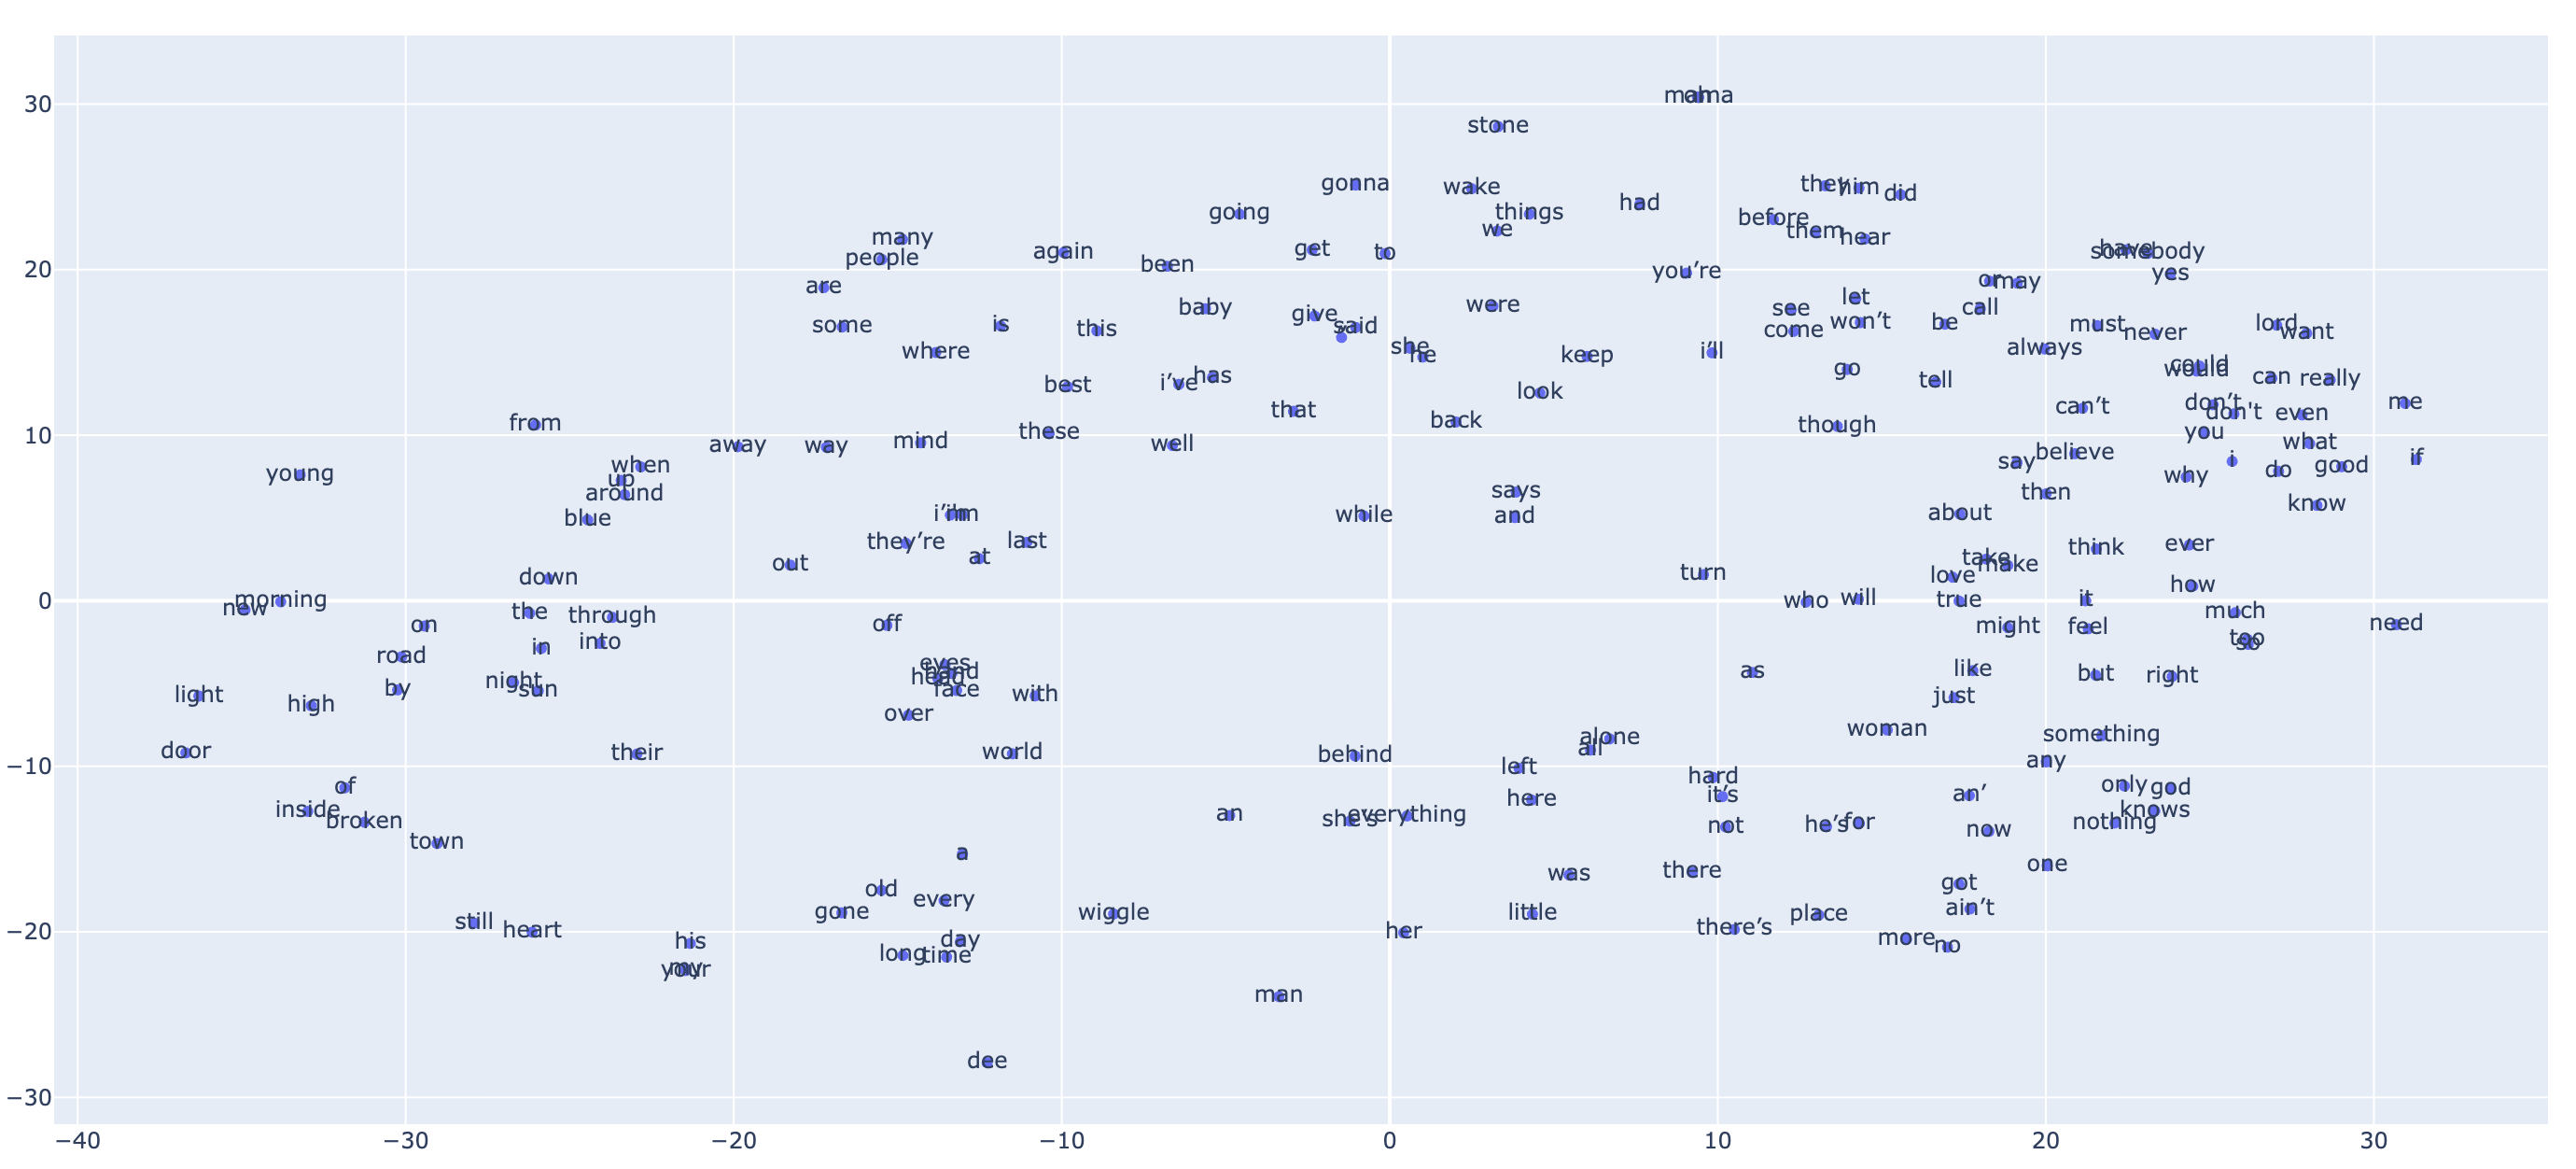

### Conclusiones finales

En este desafio se entreno un modelo de embeddings utilizando Word2Vec sobre un conjunto de letras de canciones de Bob Dylan. El objetvo del desafio fue analizar el funcionamiento del modelo y evaluar su capacidad para la captura de relaciones semanticas a partir del dataset.

Los resultados obtenidos permiten concluir que el modelo logra, en varios casos, aprender relaciones significativas entre palabras, evidenciando una adecuada representación del contexto en el que estas aparecen.

Sin embargo, también se identifican casos en los que las relaciones entre palabras parecieran estar dominadas por la co-ocurrencia dentro del conjunto de datos elegido, más que por una similitud semántica profunda. Esto es una situación esperable ya que este metodo aprende a partir del contexto local de las palabras, lo que puede llevar a asociaciones basadas en patrones de uso frecuente.

A continuación, se presentan algunos ejemplos de estos comportamientos:

1) Ejemplo 1

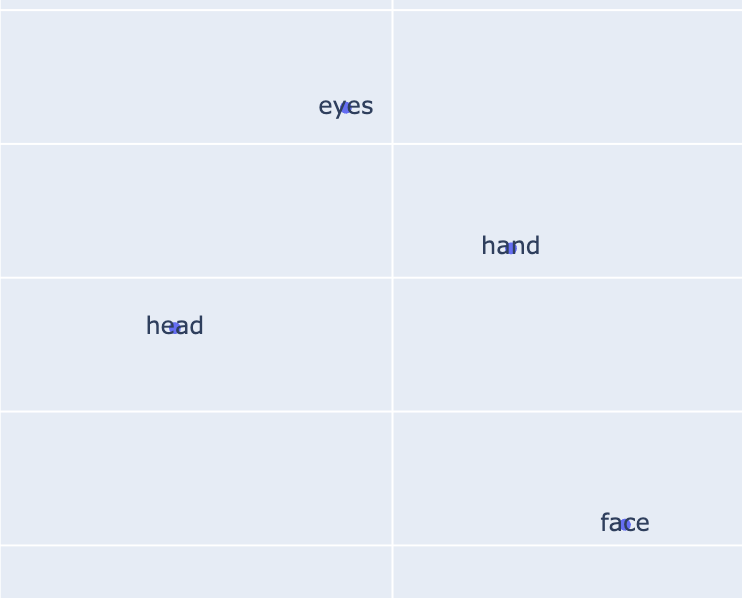

A partir de las palabras de la imagen podemos afirmar que este grupo representa partes del cuerpo/cabeza (*head, eyes, mouth, hands*). Se puede concluir que para este caso el modelo pudo capturar relaciones semanticas básicas.

Ademas si bien *hand* no es una parte de la cabeza, su proximidad puede explicarse por su uso conjunto en el contexto de demostrar una acción sobre las demas partes.

2) Ejemplo 2

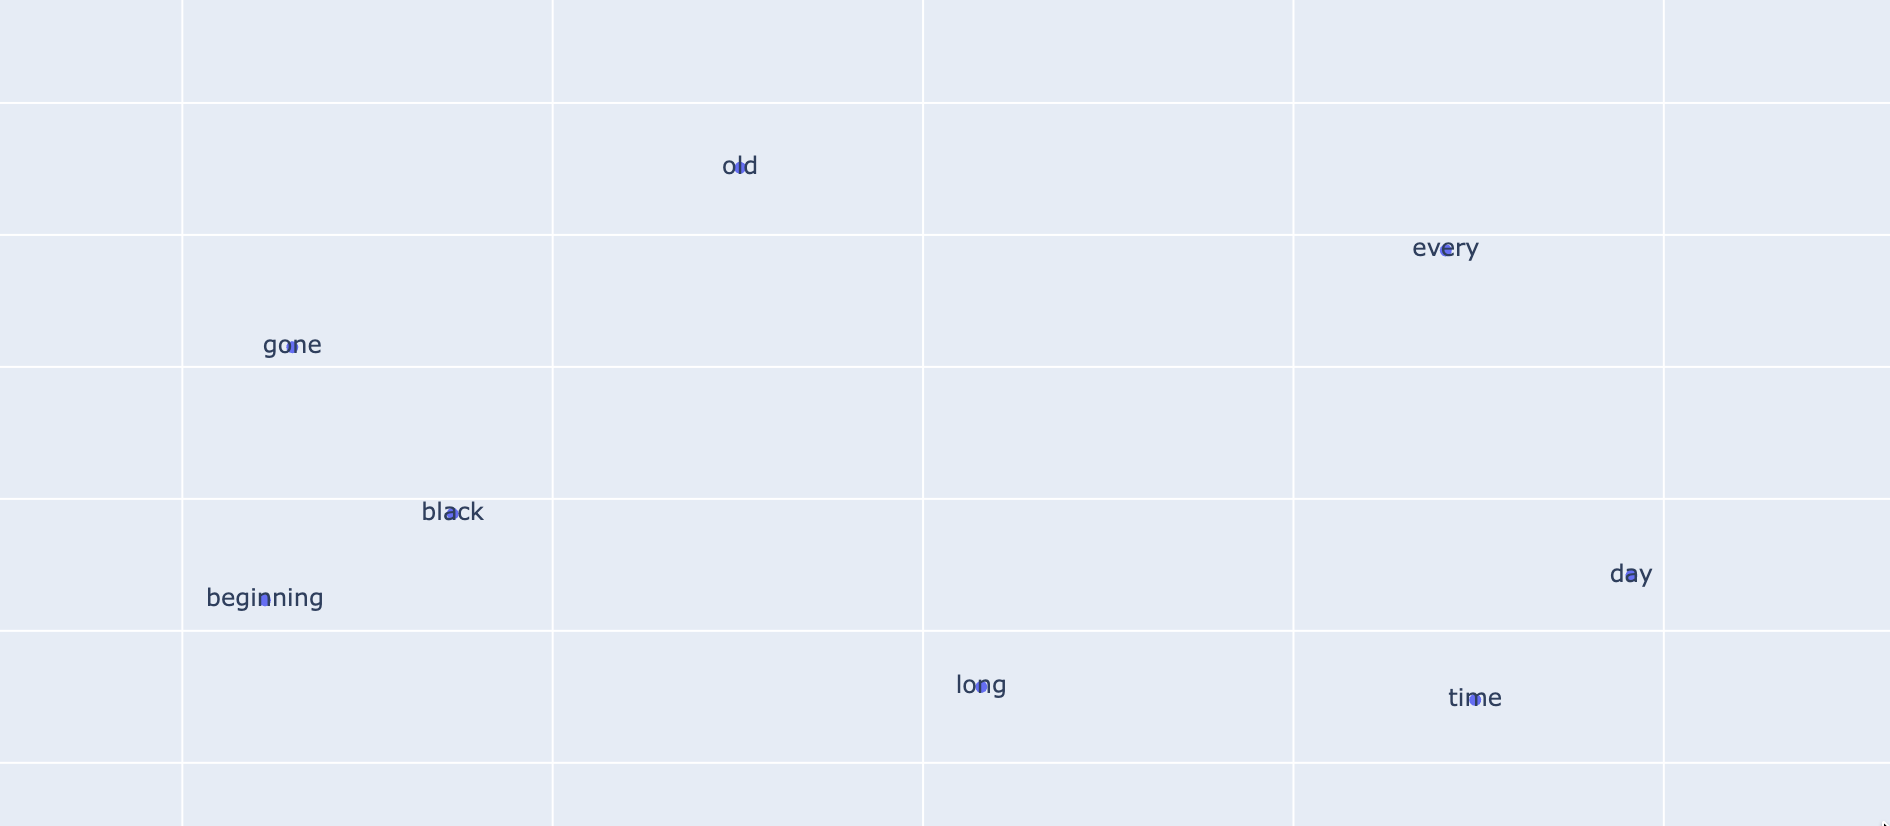
En este caso se observa un grupo de palabras asociado al **paso del tiempo** (*old, gone, long, time, every, day*), lo que refleja una coherencia en la tematica.

Es interesante la relación con la palabra *black*, la cual a simple vista no tendria una relacion directa con el paso del tiempo. Podriamos deducir que esta palabra pudo haber sido usada en un contexto de muerte u oscuridad dentro de una canción.

3) Ejemplo 3

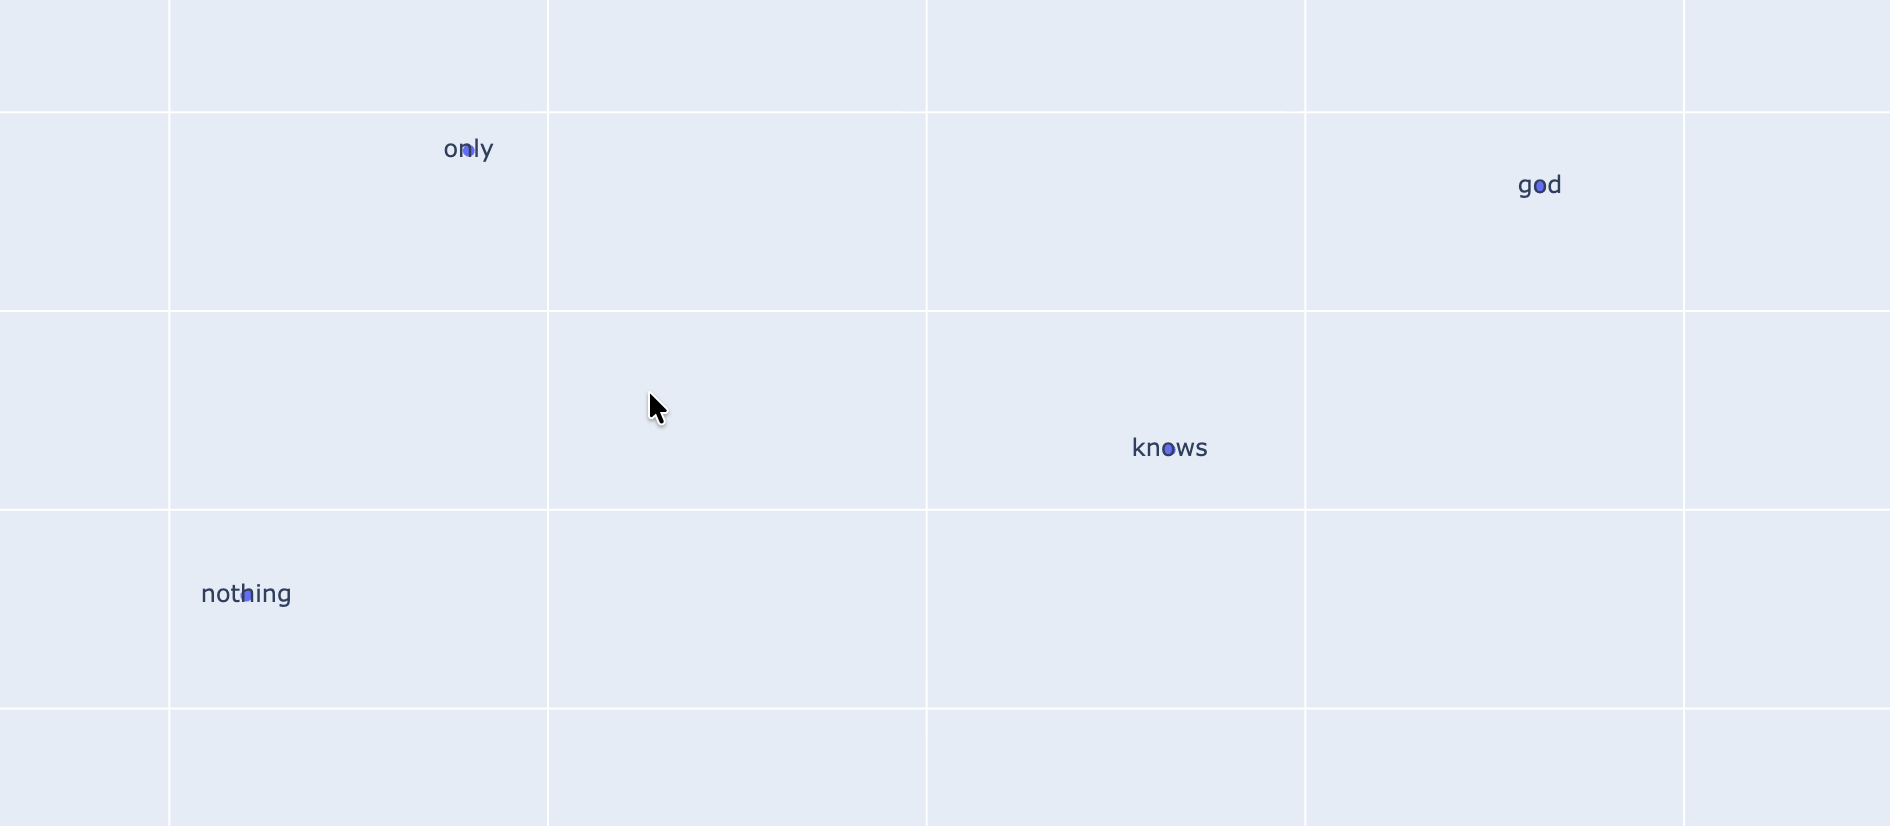

En esta última imagen se identifica un grupo de palabras compuesto por *nothing, only, god, knows*. Este conjunto resulta interesante, ya que no responde a una categoría concreta como “partes del cuerpo” o “tiempo”, sino más bien a una expresión frecuente que se utiliza en el idioma ingles "God knows" y que particularmente en este dataset set repite con frecuencia en la canción "God Knows" del autor.